In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# Load the edge list (TSV)
df = pd.read_csv("//content/string_interactions_short_gene_KG_KF_HF.tsv", sep="\t")

# Create an undirected graph using node1 and node2 columns
G = nx.from_pandas_edgelist(df, source="#node1", target="node2")


print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")

Total nodes: 240
Total edges: 486


In [ ]:
print(df.head())
print(df.dtypes)


  #node1   node2          node1_string_id          node2_string_id  \
0  ABCA1   APOA1  9913.ENSBTAP00000027538  9913.ENSBTAP00000002914   
1  ABCA1    RXRA  9913.ENSBTAP00000027538  9913.ENSBTAP00000023729   
2  ABCA1  PRKACA  9913.ENSBTAP00000027538  9913.ENSBTAP00000063436   
3   ABL1     RB1  9913.ENSBTAP00000058693  9913.ENSBTAP00000008728   
4   ABL1  STAT5B  9913.ENSBTAP00000058693  9913.ENSBTAP00000012497   

   neighborhood_on_chromosome  gene_fusion  phylogenetic_cooccurrence  \
0                           0            0                          0   
1                           0            0                          0   
2                           0            0                          0   
3                           0            0                          0   
4                           0            0                          0   

   homology  coexpression  experimentally_determined_interaction  \
0       0.0         0.052                                  0.312   
1   

In [3]:
# Find all connected components
components = list(nx.connected_components(G))
print(f"Total connected components: {len(components)}")

Total connected components: 11


In [4]:
# Check the size of each component
for i, comp in enumerate(components):
    print(f"Component {i+1}: {len(comp)} nodes")

Component 1: 216 nodes
Component 2: 2 nodes
Component 3: 2 nodes
Component 4: 2 nodes
Component 5: 2 nodes
Component 6: 3 nodes
Component 7: 4 nodes
Component 8: 2 nodes
Component 9: 2 nodes
Component 10: 2 nodes
Component 11: 3 nodes


In [5]:
# Find the largest component
largest_cc = max(nx.connected_components(G), key=len)
# Keep only that subgraph
G_main = G.subgraph(largest_cc).copy()

print(f"Filtered network nodes: {G_main.number_of_nodes()}")
print(f"Filtered network edges: {G_main.number_of_edges()}")

Filtered network nodes: 216
Filtered network edges: 472


# Filter largest 2 components

In [ ]:

# # Get all connected components sorted by size (largest first)
# components = sorted(nx.connected_components(G), key=len, reverse=True)

# # Select the top 2 largest components (13 and 11 nodes)
# top_components = components[:2]

# # Combine both into one subgraph
# combined_nodes = set().union(*top_components)
# G_main = G.subgraph(combined_nodes).copy()

# print(f"Filtered network nodes: {G_main.number_of_nodes()}")
# print(f"Filtered network edges: {G_main.number_of_edges()}")


Filtered network nodes: 279
Filtered network edges: 679


In [ ]:
# Step 4: Keep only edges where both nodes are in the largest component
df_main = df[df["#node1"].isin(largest_cc) & df["node2"].isin(largest_cc)]

# Step 5: Save the filtered network in the same STRING format
df_main.to_csv("Tharparkar_Network_filtered.tsv", sep="\t", index=False)

print(f"Filtered network saved with {len(df_main)} edges and {len(largest_cc)} nodes.")


Filtered network saved with 693 edges and 256 nodes.


In [ ]:
df_main.head(3)

,#node1,node2,node1_string_id,node2_string_id,neighborhood_on_chromosome,gene_fusion,phylogenetic_cooccurrence,homology,coexpression,experimentally_determined_interaction,database_annotated,automated_textmining,combined_score
0,CD274,IRF1,9913.ENSBTAP00000008067,9913.ENSBTAP00000041732,0,0,0.0,0.0,0.196,0.000,0.0,0.663,0.717
1,CD274,IDO1,9913.ENSBTAP00000008067,9913.ENSBTAP00000057167,0,0,0.0,0.0,0.155,0.000,0.0,0.790,0.815
2,CHUK,NFKB2,9913.ENSBTAP00000065973,9913.ENSBTAP00000007904,0,0,0.0,0.0,0.085,0.531,0.9,0.640,0.982


In [ ]:
# # Convert back to DataFrame and save
# edges_main = nx.to_pandas_edgelist(G_main)
# edges_main.to_csv("KG_network_filtered.tsv", sep="\t", index=False)

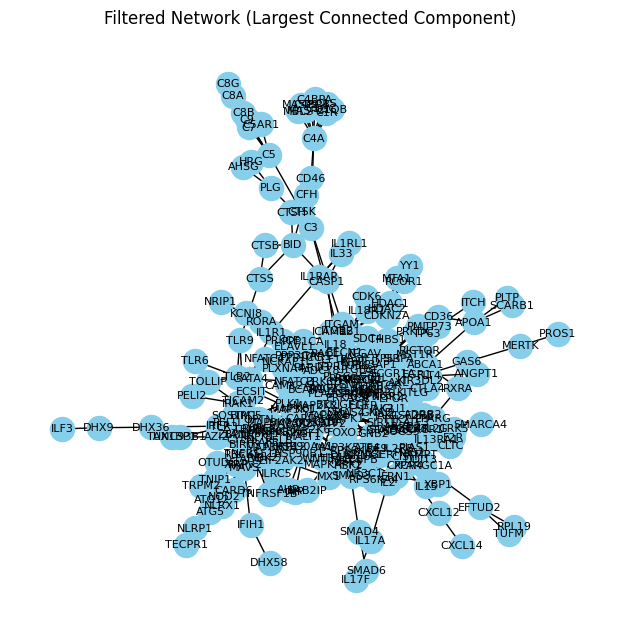

In [ ]:
# 5️⃣ Plot after filtering
plt.figure(figsize=(6, 6))
nx.draw(G_main, with_labels=True, node_size=300, font_size=8, node_color="skyblue")
plt.title("Filtered Network (Largest Connected Component)")
plt.show()

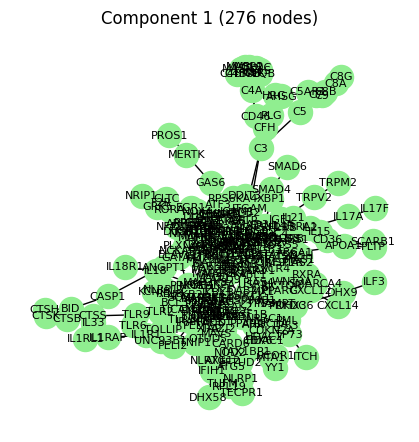

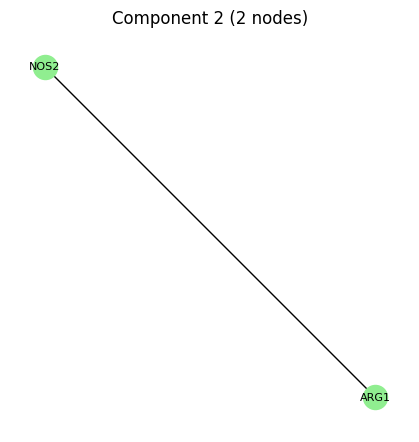

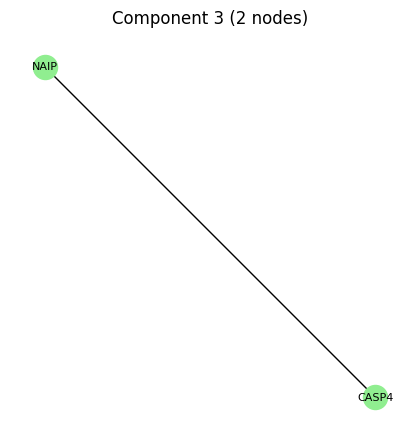

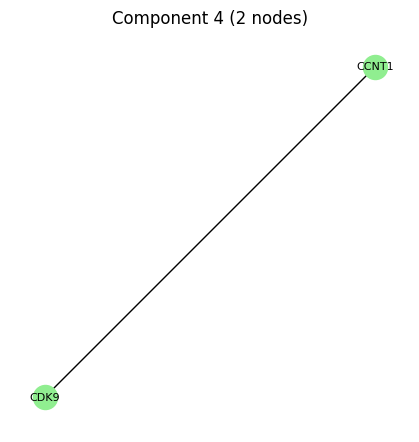

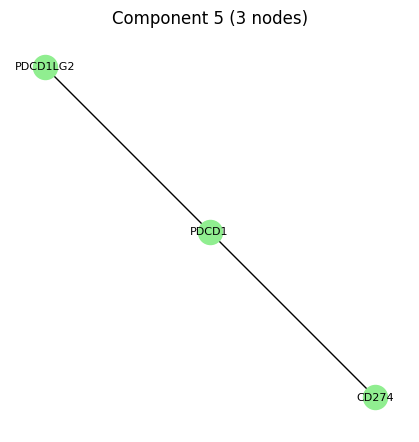

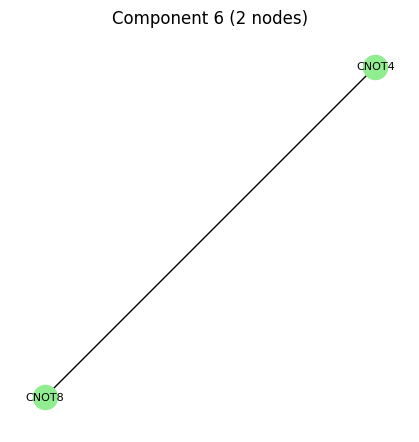

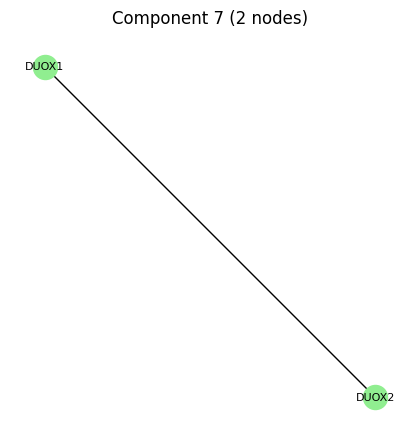

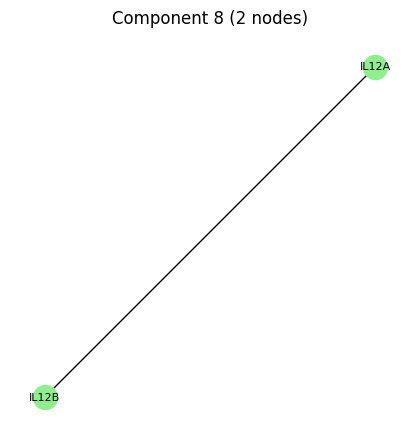

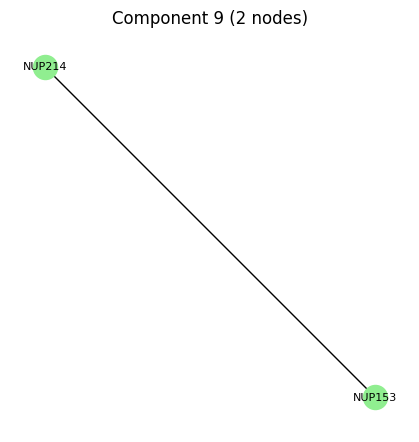

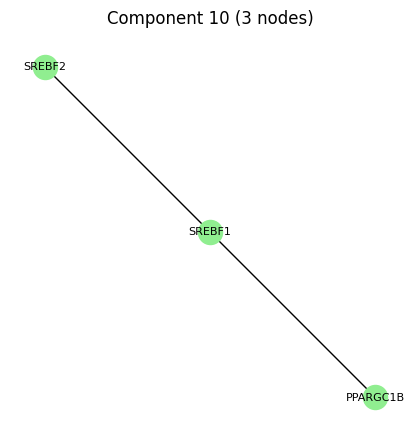

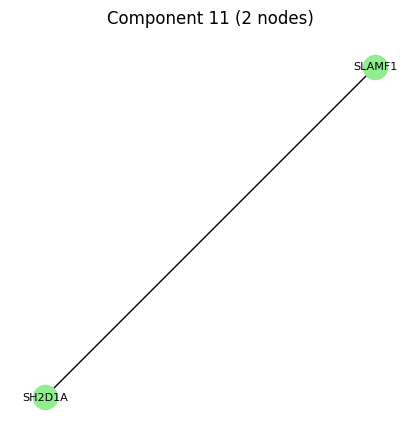

In [ ]:
components = list(nx.connected_components(G))
for i, comp in enumerate(components):
    subG = G.subgraph(comp).copy()
    plt.figure(figsize=(4, 4))
    nx.draw(subG, with_labels=True, node_color="lightgreen", node_size=300, font_size=8)
    plt.title(f"Component {i+1} ({len(comp)} nodes)")
    plt.show()


In [ ]:
print(nx.is_directed(G_main))

False


In [ ]:
# Find all cliques (complete connected subgraphs)
all_cliques = list(nx.enumerate_all_cliques(G_main))
# all_cliques

In [ ]:
# Filter only motifs with 3 or more nodes
motifs = [c for c in all_cliques if len(c) >= 3]
#motifs

In [ ]:
print(f"Total motifs (≥3 nodes): {len(motifs)}")
print("Example motifs:")
for m in motifs[:5]:
    print(m)

Total motifs (≥3 nodes): 1018
Example motifs:
['PRKACA', 'GNAI2', 'MAPK1']
['PRKACA', 'GNAI2', 'GNB2']
['PRKACA', 'GNAI2', 'IGF1R']
['PRKACA', 'MAPK1', 'ATF2']
['PRKACA', 'MAPK1', 'JUN']


In [ ]:
from collections import Counter
size_counts = Counter([len(m) for m in motifs])
print(size_counts)

Counter({3: 529, 4: 331, 5: 134, 6: 24})


In [ ]:
from collections import Counter

all_genes_in_motifs = [gene for m in motifs for gene in m]
motif_participation = Counter(all_genes_in_motifs)

# Top 10 most frequently recurring genes in motifs
for gene, freq in motif_participation.most_common(20):
    print(f"{gene}: {freq}")


PIK3R1: 372
PIK3CA: 365
PIK3CB: 364
JAK2: 230
JAK1: 181
SYK: 151
PLCG2: 107
SRC: 98
LYN: 86
PTPN6: 83
EGFR: 74
TYK2: 70
STAT5B: 67
IGF1R: 64
STAT5A: 60
BTK: 57
CBL: 56
IKBKG: 56
RAC2: 51
RIPK1: 47


In [ ]:
# import matplotlib.pyplot as plt

# # Get the neighborhood of IKBKB
# neighbors = list(G_main.neighbors("IKBKB"))
# subg = G_main.subgraph(neighbors + ["IKBKB"])

# plt.figure(figsize=(6,6))
# nx.draw(subg, with_labels=True, node_color="lightcoral", node_size=700, font_size=9, edge_color="gray")
# plt.title("Motif Neighborhood of IKBKB")
# plt.show()


In [ ]:
# nx.write_graphml(subg, "IRF1_neighborhood.graphml")
# nx.write_edgelist(subg, "IRF1_neighborhood_edges.txt", data=False)


In [ ]:
motifs_7 = [m for m in motifs if len(m) == 6]
print(f"Found {len(motifs_7)} motifs with 7 nodes.")
for m in motifs_7:
    print(m)


Found 40 motifs with 7 nodes.
['STAT5B', 'STAT5A', 'JAK2', 'JAK1', 'TYK2', 'IL2RB']
['STAT5B', 'STAT5A', 'JAK2', 'JAK1', 'TYK2', 'SOCS5']
['STAT5B', 'STAT5A', 'JAK2', 'JAK1', 'TYK2', 'PTPN2']
['NRAS', 'PIK3R1', 'PIK3CA', 'SRC', 'GNAI3', 'GNAI2']
['NRAS', 'PIK3R1', 'PIK3CA', 'SRC', 'GNAI3', 'IGF1R']
['NRAS', 'PIK3R1', 'PIK3CA', 'SRC', 'GNAI2', 'IGF1R']
['NRAS', 'PIK3R1', 'PIK3CA', 'GNAI3', 'GNAI2', 'IGF1R']
['NRAS', 'PIK3R1', 'SRC', 'GNAI3', 'GNAI2', 'IGF1R']
['NRAS', 'PIK3CA', 'SRC', 'GNAI3', 'GNAI2', 'IGF1R']
['JAK2', 'PIK3R1', 'PIK3CA', 'JAK1', 'IFNGR1', 'IFNGR2']
['JAK2', 'JAK1', 'TYK2', 'STAT1', 'IFNAR1', 'IFNGR1']
['JAK2', 'JAK1', 'TYK2', 'STAT1', 'IFNAR1', 'IFNGR2']
['JAK2', 'JAK1', 'TYK2', 'STAT1', 'IFNGR1', 'IFNGR2']
['JAK2', 'JAK1', 'TYK2', 'STAT1', 'PTPN2', 'STAT4']
['JAK2', 'JAK1', 'TYK2', 'IFNAR1', 'IFNGR1', 'IFNGR2']
['JAK2', 'JAK1', 'STAT1', 'IFNAR1', 'IFNGR1', 'IFNGR2']
['JAK2', 'TYK2', 'STAT1', 'IFNAR1', 'IFNGR1', 'IFNGR2']
['IKBKG', 'IKBKB', 'CHUK', 'NFKB1', 'NFKBIB', 

In [ ]:
# Count how often each node appears in motifs
from collections import Counter
gene_counts = Counter([gene for m in motifs for gene in m])
print(len(gene_counts))   # should be around your total nodes (192)
print(sum(gene_counts.values()))  # total appearances across all motifs


151
4496


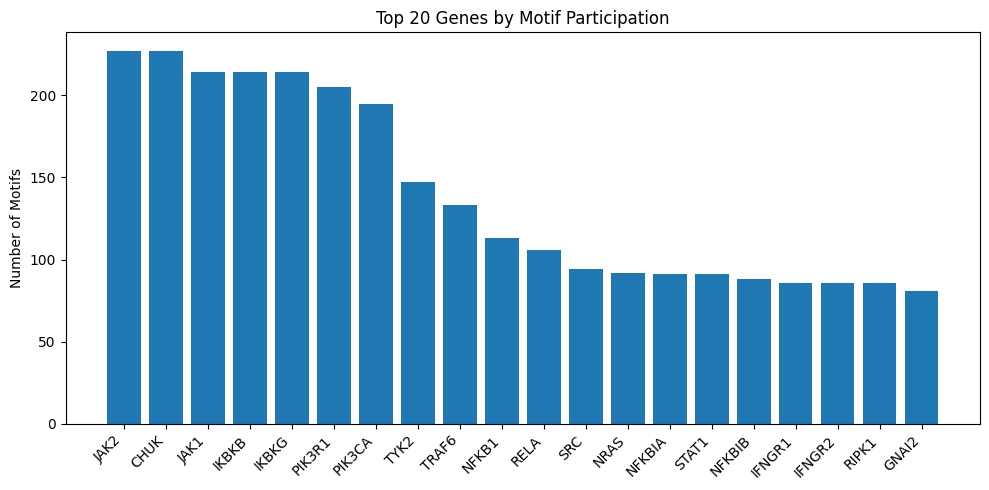

In [ ]:
import matplotlib.pyplot as plt

# Suppose gene_counts is your Counter dictionary
top_genes = dict(sorted(gene_counts.items(), key=lambda x: x[1], reverse=True)[:20])

plt.figure(figsize=(10,5))
plt.bar(top_genes.keys(), top_genes.values())
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Motifs")
plt.title("Top 20 Genes by Motif Participation")
plt.tight_layout()
plt.show()


In [6]:
# Basic properties
print(f"Nodes: {G_main.number_of_nodes()}")
print(f"Edges: {G_main.number_of_edges()}")

# Degree
degree_dict = dict(G_main.degree())

# Centralities
betweenness = nx.betweenness_centrality(G_main)
closeness = nx.closeness_centrality(G_main)
pagerank = nx.pagerank(G_main)

# Combine into dataframe
network_stats = pd.DataFrame({
    'Gene': list(G_main.nodes()),
    'Degree': [degree_dict[n] for n in G_main.nodes()],
    'Betweenness': [betweenness[n] for n in G_main.nodes()],
    'Closeness': [closeness[n] for n in G_main.nodes()],
    'PageRank': [pagerank[n] for n in G_main.nodes()]
})

# Sort by degree
network_stats.sort_values('Degree', ascending=False, inplace=True)
# network_stats.head(10)
network_stats.to_csv('Network_stat_TP.csv', index=False)
network_stats.head(10)

Nodes: 216
Edges: 472


,Gene,Degree,Betweenness,Closeness,PageRank
15,MAPK1,26,0.185636,0.333333,0.024553
50,PIK3R1,25,0.129830,0.329250,0.018991
52,PIK3CA,23,0.103898,0.327744,0.017156
43,IKBKG,21,0.127095,0.308465,0.017135
36,JAK1,20,0.086531,0.274936,0.016639
62,IKBKB,18,0.091307,0.307143,0.015515
39,PLCG2,16,0.062860,0.305832,0.012653
2,PRKACA,16,0.072951,0.300279,0.014767
114,RIPK1,15,0.072329,0.286667,0.012823
37,SRC,13,0.068464,0.304102,0.010734


In [7]:
top_hubs = network_stats.nlargest(10, 'Degree')
print("Top 10 Hub Genes:")
print(top_hubs[['Gene', 'Degree', 'PageRank']])
top_hubs.to_csv('Degree.csv', index=False)

Top 10 Hub Genes:
       Gene  Degree  PageRank
15    MAPK1      26  0.024553
50   PIK3R1      25  0.018991
52   PIK3CA      23  0.017156
43    IKBKG      21  0.017135
36     JAK1      20  0.016639
62    IKBKB      18  0.015515
39    PLCG2      16  0.012653
2    PRKACA      16  0.014767
114   RIPK1      15  0.012823
37      SRC      13  0.010734


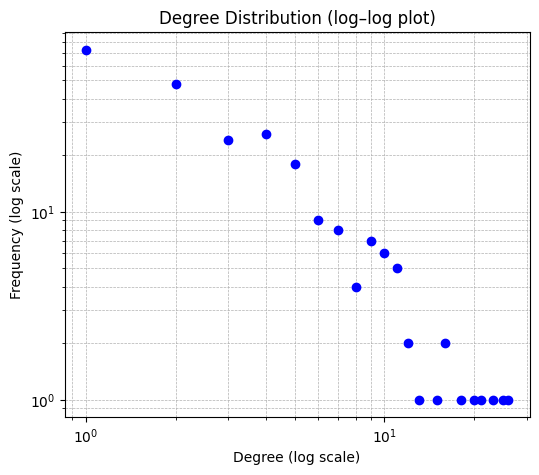

In [8]:
import numpy as np

degrees = [d for n, d in G.degree()]
unique_deg, counts = np.unique(degrees, return_counts=True)

plt.figure(figsize=(6,5))
plt.loglog(unique_deg, counts, 'bo', markersize=6)
plt.xlabel('Degree (log scale)')
plt.ylabel('Frequency (log scale)')
plt.title('Degree Distribution (log–log plot)')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()


In [ ]:
!pip install powerlaw


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 4.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import powerlaw

degrees = [d for n, d in G_main.degree()]
fit = powerlaw.Fit(degrees, discrete=True)
print(f"Estimated gamma: {fit.power_law.alpha:.2f}")


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 22/22 [00:00<00:00, 160.22it/s]

Estimated gamma: 2.56


In [ ]:
avg_degree = sum(degrees) / len(degrees)
density = nx.density(G_main)
clustering_coeff = nx.average_clustering(G_main)

print(f"Average Degree: {avg_degree:.2f}")
print(f"Network Density: {density:.4f}")
print(f"Average Clustering Coefficient: {clustering_coeff:.4f}")


Average Degree: 4.91
Network Density: 0.0178
Average Clustering Coefficient: 0.2740


In [ ]:
print(len(G_main.nodes()), len(G_main.edges()))
print(sum(dict(G_main.degree()).values()) / len(G_main))


248 656
5.290322580645161


In [ ]:
# Bottleneck = high betweenness centrality (key bridges)
betweenness = nx.betweenness_centrality(G_main, normalized=True, weight='confidence')

# Eigenvector centrality (nodes connected to other central nodes)
eigenvector = nx.eigenvector_centrality(G_main, max_iter=1000)

# Combine into DataFrame
centrality_df = pd.DataFrame({
    'Gene': list(G_main.nodes()),
    'Betweenness': [betweenness[n] for n in G_main.nodes()],
    'Eigenvector': [eigenvector[n] for n in G_main.nodes()],
    'Degree': [G_main.degree(n) for n in G_main.nodes()]
})

# Top 10 bottlenecks (high betweenness)
top_bottlenecks = centrality_df.sort_values('Betweenness', ascending=False).head(20)
top_bottlenecks.to_csv('Bottlenecks_TP.csv', index=False)

# Top 10 by eigenvector centrality
top_eigen = centrality_df.sort_values('Eigenvector', ascending=False).head(20)
top_eigen.to_csv('Eigenvectors_TP.csv', index=False)

print("Top Bottleneck Genes:")
print(top_bottlenecks)

print("\nTop Eigenvector Centrality Genes:")
print(top_eigen)


Top Bottleneck Genes:
       Gene  Betweenness  Eigenvector  Degree
29    MAPK1     0.172016     0.092534      31
99       C3     0.151772     0.016398       7
3    PRKACA     0.117277     0.060889      20
7      RAC2     0.114364     0.134524      17
59    IKBKG     0.108100     0.035200      23
65    NFKB1     0.107618     0.024296      13
103   ITGB2     0.105116     0.108350       8
134    TP53     0.086497     0.018573      12
67   PIK3R1     0.080923     0.337524      30
95      C4A     0.064234     0.001456      11
53      SRC     0.063558     0.187512      18
91    IKBKB     0.062835     0.039999      19
69   PIK3CA     0.061132     0.329570      28
88      BTK     0.058395     0.141006      10
89   PIK3CB     0.057698     0.325748      27
55    PLCG2     0.056132     0.199016      20
52     JAK1     0.054597     0.224636      23
102   ITGAM     0.050455     0.098765       7
49     MAVS     0.048008     0.009328      11
123    IL18     0.047292     0.004115       4

Top Eigenve

In [ ]:
import networkx as nx
import community as community_louvain  # for modularity (pip install python-louvain)

# --- Ensure your graph is undirected for PPI ---
G = G_main.to_undirected()

# ---- 1️⃣  Average Path Length ----
# (only works for connected graphs, so take the largest connected component)
largest_cc = max(nx.connected_components(G), key=len)
G_cc = G.subgraph(largest_cc)
avg_path_length = nx.average_shortest_path_length(G_cc)
print(f"Average path length: {avg_path_length:.3f}")

# ---- 2️⃣  Diameter ----
diameter = nx.diameter(G_cc)
print(f"Network diameter: {diameter}")

# ---- 3️⃣  Modularity ----
# Detect community structure using Louvain method
partition = community_louvain.best_partition(G)
modularity = community_louvain.modularity(partition, G)
print(f"Modularity: {modularity:.3f}")

# ---- 4️⃣  Assortativity ----
# Measures tendency of nodes to connect with similar-degree nodes
assortativity = nx.degree_assortativity_coefficient(G)
print(f"Assortativity: {assortativity:.3f}")

# ---- 5️⃣  Optional: Centrality Stats ----
degree_centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)
avg_betweenness = sum(betweenness.values()) / len(betweenness)
print(f"Average betweenness centrality: {avg_betweenness:.5f}")


Average path length: 4.434
Network diameter: 11
Modularity: 0.604
Assortativity: 0.052
Average betweenness centrality: 0.01253


In [ ]:
import networkx as nx
import numpy as np

def compute_network_stats(G):
    stats = {}
    stats["Total_nodes"] = G.number_of_nodes()
    stats["Total_edges"] = G.number_of_edges()
    stats["Average_degree"] = np.mean([d for _, d in G.degree()])
    stats["Density"] = nx.density(G)
    stats["Average_clustering"] = nx.average_clustering(G)

    # Handle disconnected networks gracefully
    if nx.is_connected(G):
        stats["Average_path_length"] = nx.average_shortest_path_length(G)
        stats["Diameter"] = nx.diameter(G)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        sub = G.subgraph(largest_cc)
        stats["Average_path_length"] = nx.average_shortest_path_length(sub)
        stats["Diameter"] = nx.diameter(sub)

    # Modularity
    from networkx.algorithms.community import greedy_modularity_communities
    comms = list(greedy_modularity_communities(G))
    stats["Modularity"] = nx.algorithms.community.quality.modularity(G, comms)

    # Assortativity
    stats["Assortativity"] = nx.degree_assortativity_coefficient(G)

    return stats


In [ ]:
real_stats = compute_network_stats(G_main)
print("Real Network Stats:\n", real_stats)


Real Network Stats:
 {'Total_nodes': 276, 'Total_edges': 677, 'Average_degree': np.float64(4.905797101449275), 'Density': 0.017839262187088274, 'Average_clustering': 0.27396123282869167, 'Average_path_length': 4.433833992094861, 'Diameter': 11, 'Modularity': 0.6116643284627419, 'Assortativity': 0.051928813217624534}


In [ ]:
import networkx as nx
import numpy as np

# -------------------------------
# Step 1: Generate random networks
# -------------------------------
num_random_networks = 100
random_networks = []

for i in range(num_random_networks):
    G_rand = G_main.copy()
    nx.double_edge_swap(
        G_rand,
        nswap=2 * G_main.number_of_edges(),
        max_tries=10000
    )
    random_networks.append(G_rand)

print(f"Generated {len(random_networks)} degree-preserving random networks")

# --------------------------------
# Step 2: Calculate network metrics
# --------------------------------
nodes = []
edges = []
density = []
avg_degree = []
avg_clustering = []
avg_path_length = []

for Gr in random_networks:
    nodes.append(Gr.number_of_nodes())
    edges.append(Gr.number_of_edges())
    density.append(nx.density(Gr))
    avg_degree.append(np.mean([d for _, d in Gr.degree()]))
    avg_clustering.append(nx.average_clustering(Gr))

    # Handle disconnected networks safely
    if nx.is_connected(Gr):
        avg_path_length.append(nx.average_shortest_path_length(Gr))
    else:
        largest_cc = Gr.subgraph(max(nx.connected_components(Gr), key=len))
        avg_path_length.append(
            nx.average_shortest_path_length(largest_cc)
        )

# --------------------------------
# Step 3: Print mean ± SD
# --------------------------------
print("\nRandom Network Statistics (mean ± SD):")
print(f"Nodes: {np.mean(nodes):.2f} ± {np.std(nodes):.2f}")
print(f"Edges: {np.mean(edges):.2f} ± {np.std(edges):.2f}")
print(f"Density: {np.mean(density):.4f} ± {np.std(density):.4f}")
print(f"Average degree: {np.mean(avg_degree):.2f} ± {np.std(avg_degree):.2f}")
print(f"Average clustering: {np.mean(avg_clustering):.4f} ± {np.std(avg_clustering):.4f}")
print(f"Average path length: {np.mean(avg_path_length):.2f} ± {np.std(avg_path_length):.2f}")
print(f"Diameter: {np.mean(diameter):.2f} ± {np.std(diameter):.2f}")
print(f"Avg betweenness centrality: {np.mean(avg_betweenness):.6f} ± {np.std(avg_betweenness):.6f}")
print(f"Modularity: {np.mean(modularity):.4f} ± {np.std(modularity):.4f}")
print(f"Assortativity: {np.mean(assortativity):.4f} ± {np.std(assortativity):.4f}")


Generated 100 degree-preserving random networks

Random Network Statistics (mean ± SD):
Nodes: 276.00 ± 0.00
Edges: 677.00 ± 0.00
Density: 0.0178 ± 0.0000
Average degree: 4.91 ± 0.00
Average clustering: 0.0546 ± 0.0085
Average path length: 3.42 ± 0.04
Diameter: 11.00 ± 0.00
Avg betweenness centrality: 0.012532 ± 0.000000
Modularity: 0.6044 ± 0.0000
Assortativity: 0.0519 ± 0.0000


# Convert PPI to Gene regulatory **network**

In [ ]:

# Load list of TFs
tfs = pd.read_csv("/content/Bos_taurus_TF.csv")  # column 'GeneSymbol'

# Clean TF symbols: remove NaN, whitespace, and standardize to uppercase
tfs = tfs.dropna(subset=['Symbol'])
tf_set = set(tfs['Symbol'].astype(str).str.strip().str.upper())

# Assign is_TF attribute
for node in G_main.nodes:
    G_main.nodes[node]['is_TF'] = node.strip().upper() in tf_set

# # Mark which nodes are TFs
# for node in G_main.nodes():
#     G_main.nodes[node]['is_TF'] = node in tf_set
# Check how many TFs were found in the network
sum(nx.get_node_attributes(G_main, 'is_TF').values())


46

In [ ]:
tfs.head(3)

,Species,Symbol,Ensembl,Family,Protein,Entrez_ID
0,Bos_taurus,ZFP69,ENSBTAG00000039287,zf-C2H2,ENSBTAP00000061159.1;ENSBTAP00000048845.1;,521549.0
1,Bos_taurus,EN2,ENSBTAG00000018917,Homeobox,ENSBTAP00000028648.6;,100337304.0
2,Bos_taurus,ZNF513,ENSBTAG00000019518,zf-C2H2,ENSBTAP00000025999.5;,100138621.0


In [ ]:
import networkx as nx

GRN = nx.DiGraph()

for u, v in G_main.edges():
    u_TF = G_main.nodes[u]['is_TF']
    v_TF = G_main.nodes[v]['is_TF']

    # Case 1: TF → target (classical regulation)
    if u_TF and not v_TF:
        GRN.add_edge(u, v)
    elif v_TF and not u_TF:
        GRN.add_edge(v, u)
    # Case 2: TF → TF (cascade regulation)
    elif u_TF and v_TF:
        GRN.add_edge(u, v)


In [ ]:
# 1️⃣ Check total nodes marked as TF
num_tfs_in_network = sum(nx.get_node_attributes(G_main, 'is_TF').values())
print("Number of TFs in G_main:", num_tfs_in_network)

# 2️⃣ (Optional) See first few nodes with their is_TF status
for n, d in list(G_main.nodes(data=True))[:10]:
    print(n, "→ is_TF:", d.get('is_TF', 'Not defined'))

# 3️⃣ (Optional) Get all nodes identified as TFs
tfs_in_network = [n for n, d in G_main.nodes(data=True) if d.get('is_TF')]
print("TFs found in G_main:", tfs_in_network[:20])  # show first 20

Number of TFs in G_main: 46
AAMP → is_TF: False
EGFR → is_TF: False
NOD2 → is_TF: False
ABCA1 → is_TF: False
APOA1 → is_TF: False
RXRA → is_TF: True
PRKACA → is_TF: False
ABL1 → is_TF: False
RB1 → is_TF: False
STAT5B → is_TF: True
TFs found in G_main: ['RXRA', 'STAT5B', 'STAT5A', 'AHR', 'JUN', 'FOXO3', 'GLI1', 'ATF2', 'IRF3', 'ATF4', 'CREB1', 'CEBPB', 'TAX1BP1', 'NFKB1', 'NFKB2', 'RELA', 'RELB', 'IRF7', 'HIF1A', 'EGR1']


In [ ]:
from collections import Counter
from itertools import combinations

# Find all directed motifs (3+ nodes)
motifs = [c for c in nx.enumerate_all_cliques(GRN.to_undirected()) if len(c) >= 2]
size_counts = Counter([len(m) for m in motifs])
print(size_counts)

# Identify top TF hubs
tf_hubs = sorted(GRN.out_degree, key=lambda x: x[1], reverse=True)[:10]
for tf, deg in tf_hubs:
    print(f"{tf}: {deg}")


Counter({2: 187, 3: 74, 4: 12, 5: 1})
STAT1: 18
NFKB1: 17
STAT5B: 13
RELA: 13
STAT5A: 12
JUN: 9
ATF2: 7
ATF4: 7
CREB1: 7
FOXO3: 7


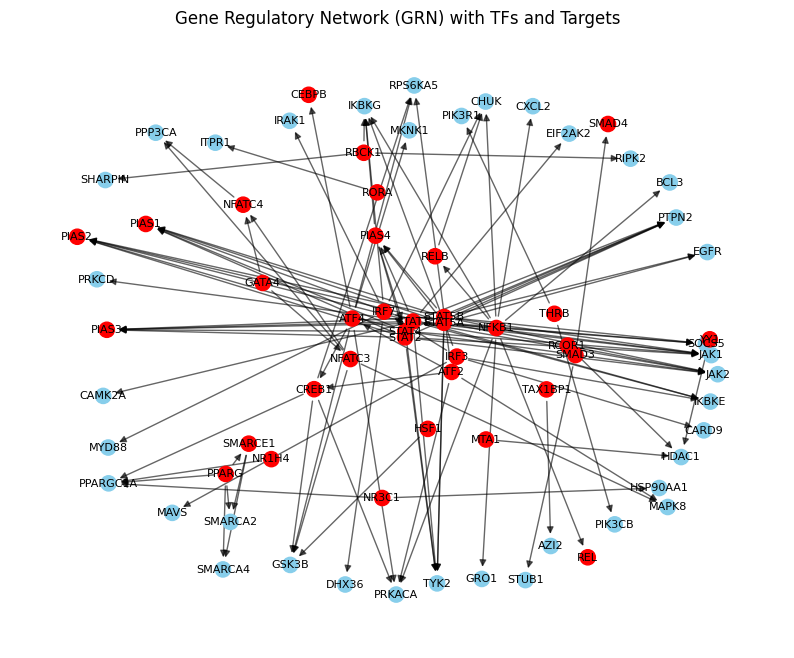

In [ ]:
node_colors = []
for n in GRN.nodes():
    if G_main.nodes[n]['is_TF']:
        node_colors.append('red')      # TFs → red
    else:
        node_colors.append('skyblue')  # targets → blue

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(GRN, k=0.4)
nx.draw_networkx_nodes(GRN, pos, node_color=node_colors, node_size=120)
nx.draw_networkx_edges(GRN, pos, arrows=True, alpha=0.6)
nx.draw_networkx_labels(GRN, pos, font_size=8)
plt.title("Gene Regulatory Network (GRN) with TFs and Targets")
plt.axis('off')
plt.show()
nx.write_graphml(GRN, "GRN_TF_Target.graphml")


TFs found in G_main: 46
[('STAT5B', {'is_TF': True}), ('EGFR', {'is_TF': False}), ('STAT5A', {'is_TF': True}), ('RXRA', {'is_TF': True}), ('ABCA1', {'is_TF': False})]


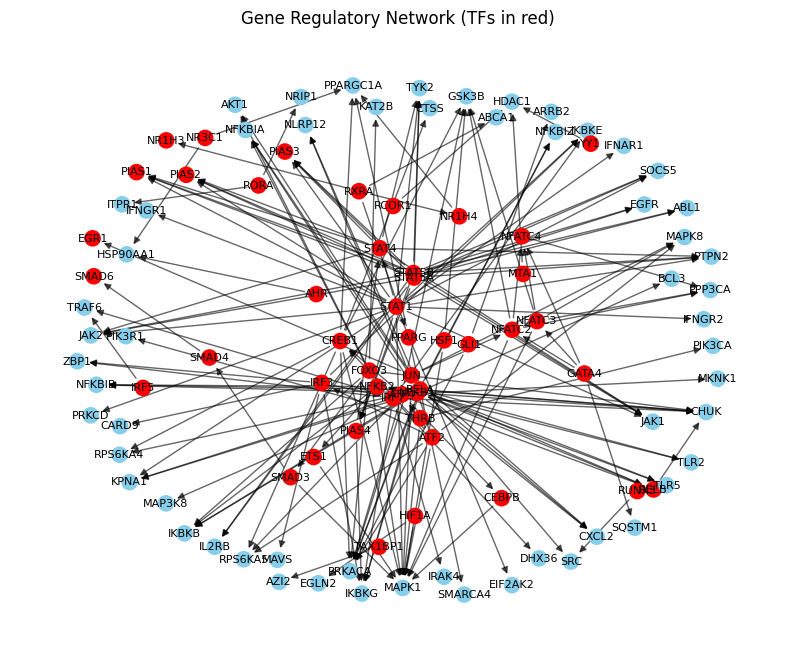

GraphML exported successfully.


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load TF list
# -------------------------------
tfs = pd.read_csv("/content/Bos_taurus_TF.csv")

# Clean TF symbols
tfs = tfs.dropna(subset=['Symbol'])
tf_set = set(tfs['Symbol'].astype(str).str.strip().str.upper())

# -------------------------------
# 2. Assign TF status to G_main
# -------------------------------
for node in G_main.nodes():
    G_main.nodes[node]['is_TF'] = node.strip().upper() in tf_set

print("TFs found in G_main:",
      sum(nx.get_node_attributes(G_main, 'is_TF').values()))

# -------------------------------
# 3. Ensure GRN is directed
# -------------------------------
if not GRN.is_directed():
    GRN = nx.DiGraph(GRN)

# -------------------------------
# 4. COPY TF attribute into GRN
# -------------------------------
for node in GRN.nodes():
    GRN.nodes[node]['is_TF'] = G_main.nodes.get(node, {}).get('is_TF', False)

# Verify (IMPORTANT)
print(list(GRN.nodes(data=True))[:5])

# -------------------------------
# 5. (Optional) Quick Python visualization
# -------------------------------
node_colors = [
    'red' if GRN.nodes[n]['is_TF'] else 'skyblue'
    for n in GRN.nodes()
]

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(GRN, k=0.4, seed=42)
nx.draw_networkx_nodes(GRN, pos, node_color=node_colors, node_size=120)
nx.draw_networkx_edges(GRN, pos, arrows=True, alpha=0.6)
nx.draw_networkx_labels(GRN, pos, font_size=8)
plt.title("Gene Regulatory Network (TFs in red)")
plt.axis('off')
plt.show()

# -------------------------------
# 6. Export for Cytoscape
# -------------------------------
nx.write_graphml(GRN, "GRN_TF_Target.graphml")
print("GraphML exported successfully.")


In [ ]:
print(list(GRN.nodes(data=True))[:20])


[('STAT5B', {'is_TF': True}), ('EGFR', {'is_TF': False}), ('STAT5A', {'is_TF': True}), ('RXRA', {'is_TF': True}), ('ABCA1', {'is_TF': False}), ('NR1H3', {'is_TF': True}), ('NR1H4', {'is_TF': True}), ('PPARG', {'is_TF': True}), ('ATF2', {'is_TF': True}), ('PRKACA', {'is_TF': False}), ('ATF4', {'is_TF': True}), ('CREB1', {'is_TF': True}), ('FOXO3', {'is_TF': True}), ('GLI1', {'is_TF': True}), ('JUN', {'is_TF': True}), ('NFKB1', {'is_TF': True}), ('RELA', {'is_TF': True}), ('ABL1', {'is_TF': False}), ('IL2RB', {'is_TF': False}), ('JAK1', {'is_TF': False})]


# Detect directed 3-node motifs: feed-forward loops (FFLs) and 3-cycles

In [ ]:
import networkx as nx
from collections import Counter
import pandas as pd

# --- Feed-forward loops (A -> B, A -> C, B -> C) ---
ffls = []
for a in GRN.nodes():
    for b in GRN.successors(a):
        for c in GRN.successors(b):
            if GRN.has_edge(a, c):
                ffls.append((a, b, c))
# remove duplicates (they should be unique in this enumeration)
ffls = list(dict.fromkeys(ffls))

# --- 3-node directed cycles (A->B->C->A) ---
three_cycles = []
for cycle in nx.simple_cycles(GRN):
    if len(cycle) == 3:
        # normalize cycle order for uniqueness (rotate so min node first)
        min_idx = min(range(3), key=lambda i: cycle[i])
        norm = tuple(cycle[min_idx:] + cycle[:min_idx])
        three_cycles.append(norm)
# unique
three_cycles = list(dict.fromkeys(three_cycles))

print("Feed-forward loops (FFLs):", len(ffls))
print("3-node directed cycles:", len(three_cycles))


Feed-forward loops (FFLs): 74
3-node directed cycles: 0


In [ ]:
# Save FFLs
df_ffl = pd.DataFrame(ffls, columns=["TF1","TF2","Target"])
df_ffl.to_csv("GRN_FFLs.tsv", sep="\t", index=False)

# Save 3-cycles
df_3cycle = pd.DataFrame(three_cycles, columns=["A","B","C"])
df_3cycle.to_csv("GRN_3cycles.tsv", sep="\t", index=False)

df_ffl

,TF1,TF2,Target
0,STAT5B,STAT5A,EGFR
1,STAT5B,STAT5A,ABL1
2,STAT5B,STAT5A,IL2RB
3,STAT5B,STAT5A,JAK1
4,STAT5B,STAT5A,JAK2
...,...,...,...
69,NFKB2,RELA,RELB
70,NFKB2,RELB,CHUK
71,GATA4,NFATC3,NFATC2
72,GATA4,NFATC3,NFATC4


In [ ]:
import os
import matplotlib.pyplot as plt

os.makedirs("motif_plots1/ffl", exist_ok=True)
os.makedirs("motif_plots1/3cycle", exist_ok=True)

def plot_subgraph(nodes, G, filename, highlight=None):
    sub = G.subgraph(nodes).copy()
    pos = nx.spring_layout(sub, seed=42)  # stable layout
    # node coloring: red=TF (in tf_set), orange=TF but not top hub, blue=target
    node_colors = []
    sizes = []
    labels = {n: n for n in sub.nodes()}
    for n in sub.nodes():
        is_tf = G.nodes[n].get('is_TF', False)
        if highlight and n in highlight:
            node_colors.append('red')    # highlight nodes (top regulator)
            sizes.append(800)
        elif is_tf:
            node_colors.append('orange')
            sizes.append(500)
        else:
            node_colors.append('skyblue')
            sizes.append(400)
    plt.figure(figsize=(3.5,3.5))
    nx.draw_networkx_nodes(sub, pos, node_color=node_colors, node_size=sizes)
    nx.draw_networkx_edges(sub, pos, arrows=True, arrowsize=12, edge_color='black', width=1.2)
    nx.draw_networkx_labels(sub, pos, labels, font_size=8)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.close()

# Plot first 20 FFLs
for i, (a,b,c) in enumerate(ffls[:200]):  # change slice as needed
    plot_subgraph([a,b,c], GRN, f"motif_plots1/ffl/ffl_{i+1}_{a}_{b}_{c}.png", highlight=[a])
# Plot 3-cycles
for i, (a,b,c) in enumerate(three_cycles[:200]):
    plot_subgraph([a,b,c], GRN, f"motif_plots1/3cycle/3cycle_{i+1}_{a}_{b}_{c}.png")


# Identify master regulators (hub TFs) and motif participation

In [ ]:
from collections import Counter
import numpy as np

# Out-degree (TFs regulating many targets)
out_deg = dict(GRN.out_degree())
top_outdeg = sorted(out_deg.items(), key=lambda x: x[1], reverse=True)[:20]

# Pagerank (importance in directed graph)
pr = nx.pagerank(GRN)
top_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:20]

# Motif participation: how often does each node appear in FFLs or 3-cycles?
part_counter = Counter()
for a,b,c in ffls:
    part_counter.update([a,b,c])
for a,b,c in three_cycles:
    part_counter.update([a,b,c])

# Tabulate top candidates
records = []
for node, deg in top_outdeg[:20]:
    records.append({
        'Gene': node,
        'Out_degree': deg,
        'PageRank': pr.get(node,0),
        'Motif_Participation': part_counter.get(node,0),
        'is_TF': GRN.nodes[node].get('is_TF', True)
    })
df_hubs = pd.DataFrame(records).sort_values(['Out_degree','Motif_Participation'], ascending=False)
df_hubs.to_csv("GRN_candidate_master_regulators.csv", index=False)
df_hubs.head(10)


,Gene,Out_degree,PageRank,Motif_Participation,is_TF
0,STAT1,18,0.007040,8,True
1,NFKB1,17,0.007040,20,True
3,RELA,13,0.008290,20,True
2,STAT5B,13,0.007040,12,True
4,STAT5A,12,0.007500,12,True
5,JUN,9,0.007040,4,True
12,NFKB2,7,0.007392,12,True
6,ATF2,7,0.007705,9,True
8,CREB1,7,0.008944,8,True
10,STAT4,7,0.010927,8,True


# Detect mutual (2-node) regulation and longer loops

In [ ]:
# Mutual pairs (A->B and B->A)
mutual_pairs = [(u,v) for u,v in GRN.edges() if GRN.has_edge(v,u) and u < v]
print("Mutual regulatory pairs:", len(mutual_pairs))

# All directed cycles of length <= 6 (be careful: can be expensive)
cycles = [c for c in nx.simple_cycles(GRN) if len(c) <= 6]
print("Total cycles (len<=6):", len(cycles))


Mutual regulatory pairs: 0
Total cycles (len<=6): 0


# Visualize GRN with highlighted top regulators and label top 5

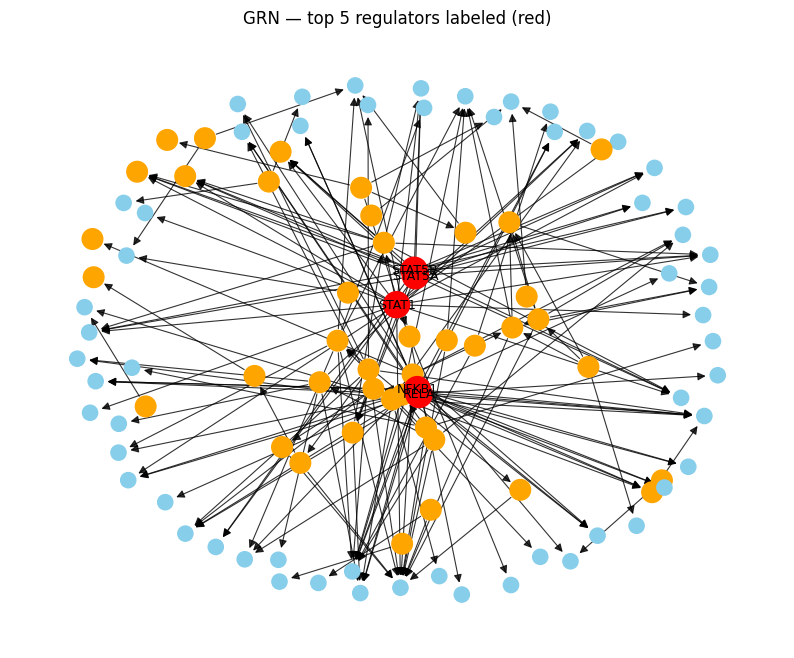

In [ ]:
import matplotlib.pyplot as plt

# Choose top 5 by Out_degree or motif participation
top5 = list(df_hubs['Gene'].head(5))

pos = nx.spring_layout(GRN, k=0.45, seed=42)
plt.figure(figsize=(10,8))

# color nodes: red top5, orange other TFs, blue targets
node_color = []
node_size = []
labels = {}
for n in GRN.nodes():
    if n in top5:
        node_color.append('red'); node_size.append(350)
        labels[n] = n
    elif GRN.nodes[n].get('is_TF', False):
        node_color.append('orange'); node_size.append(220)
    else:
        node_color.append('skyblue'); node_size.append(120)

nx.draw_networkx_nodes(GRN, pos, node_color=node_color, node_size=node_size)
nx.draw_networkx_edges(GRN, pos, arrows=True, arrowsize=12, width=0.8, alpha=0.8)
nx.draw_networkx_labels(GRN, pos, labels, font_size=9)
plt.title("GRN — top 5 regulators labeled (red)")
plt.axis('off')
plt.show()


In [ ]:
# For directed GRN
out_deg = dict(GRN.out_degree())
in_deg = dict(GRN.in_degree())

# Centralities
betweenness = nx.betweenness_centrality(GRN)
pagerank = nx.pagerank(GRN, alpha=0.85)

# Combine into dataframe
import pandas as pd

grn_stats = pd.DataFrame({
    'Gene': list(GRN.nodes()),
    'Out_Degree': [out_deg.get(n, 0) for n in GRN.nodes()],
    'In_Degree': [in_deg.get(n, 0) for n in GRN.nodes()],
    'Betweenness': [betweenness.get(n, 0) for n in GRN.nodes()],
    'PageRank': [pagerank.get(n, 0) for n in GRN.nodes()],
})

print(grn_stats.sort_values(by='Out_Degree', ascending=False).head(20))


      Gene  Out_Degree  In_Degree  Betweenness  PageRank
28   STAT1          18          0     0.000000  0.007040
15   NFKB1          17          0     0.000000  0.007040
0   STAT5B          13          0     0.000000  0.007040
16    RELA          13          2     0.000761  0.008290
2   STAT5A          12          1     0.000000  0.007500
14     JUN           9          0     0.000000  0.007040
11   CREB1           7          2     0.000761  0.008944
12   FOXO3           7          0     0.000000  0.007040
30   STAT4           7          2     0.000666  0.010927
8     ATF2           7          1     0.001808  0.007705
10    ATF4           7          1     0.000524  0.007976
42    IRF7           7          1     0.001142  0.008170
56   NFKB2           7          1     0.000190  0.007392
48  NFATC3           6          1     0.000222  0.008536
43    IRF3           6          1     0.001904  0.007976
37  NFATC2           4          3     0.000412  0.010410
3     RXRA           4         

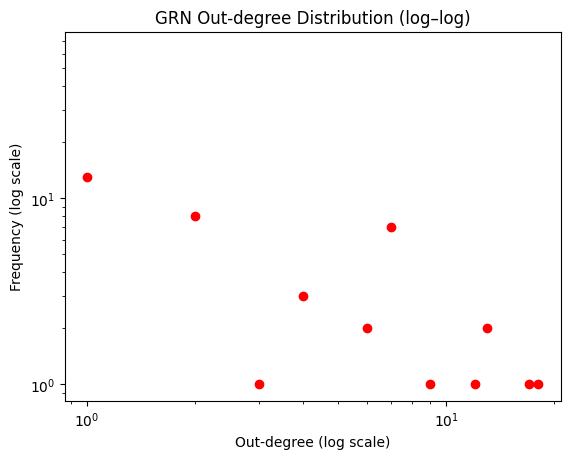

In [ ]:
out_degrees = [d for n, d in GRN.out_degree()]
plt.figure()
plt.loglog(*np.unique(out_degrees, return_counts=True), 'ro')
plt.xlabel("Out-degree (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("GRN Out-degree Distribution (log–log)")
plt.show()


In [ ]:
from itertools import combinations

motifs_4_directed = []
for nodes in combinations(GRN.nodes(), 4):
    sub = GRN.subgraph(nodes)
    # ensure at least 5 edges among 4 nodes → densely connected
    if sub.number_of_edges() >= 5:
        motifs_4_directed.append(tuple(nodes))

print(f"Directed 4-node motifs: {len(motifs_4_directed)}")

Directed 4-node motifs: 243


In [ ]:
nx.write_graphml(GRN, "GRN_network.graphml")
nx.write_edgelist(GRN, "GRN_network.csv", delimiter=",", data=False)


In [ ]:
import pandas as pd

# Extract edges from GRN (directed)
edges = list(GRN.edges())

# Create dataframe with column names
df_edges = pd.DataFrame(edges, columns=["source", "target"])

# Save as CSV
df_edges.to_csv("GRN_network.csv", index=False)
